In [ ]:
%load_ext autoreload

import numpy as np
import matplotlib.pyplot as plt
import awkward
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool
from torch_geometric.nn import DynamicEdgeConv


/home/freddy/miniforge3/envs/torch_geometric/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:

%autoreload 2

from helper import normalize_dataset, collate_fn_gnn, train_model, plot_loss, evaluate_model, load_best_model

<unknown>:359: SyntaxWarning: invalid escape sequence '\D'
<unknown>:389: SyntaxWarning: invalid escape sequence '\D'
<unknown>:473: SyntaxWarning: invalid escape sequence '\D'
<unknown>:486: SyntaxWarning: invalid escape sequence '\D'
<unknown>:359: SyntaxWarning: invalid escape sequence '\D'
<unknown>:389: SyntaxWarning: invalid escape sequence '\D'
<unknown>:425: SyntaxWarning: invalid escape sequence '\D'


In [ ]:
DATA_PATH = "./data_pq/"  # path to the data

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [4]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

In [5]:
# Normalize data and labels
# 1. Normalize the training set (computes and returns the stats)
train_dataset, train_stats = normalize_dataset(train_dataset)

# 2. Normalize the validation set (using the stats from train)
val_dataset, _ = normalize_dataset(val_dataset, stats=train_stats)

# 3. Normalize the test set (using the stats from train)
test_dataset, _ = normalize_dataset(test_dataset, stats=train_stats)

In [6]:
# Create the DataLoader for training, validation, and test datasets
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)

In [7]:
sample_data, sample_labels = next(iter(train_loader))
print("Label Shape:", sample_labels.shape)
print("Sample Labels:", sample_labels[0])

Label Shape: torch.Size([32, 2])
Sample Labels: tensor([0.0160, 3.4900])


In [8]:
# Definition of the GNN model
# Use the DynamicEdgeConv layer from the pytorch geometric package like this:
# MLP is a Multi-Layer Perceptron that is used to compute the edge features, you still need to define it.
# The input dimension to the MLP should be twice the number of features in the input data (i.e., 2 * n_features),
# because the edge features are computed from the concatenation of the two nodes that are connected by the edge.
# The output dimension of the MLP is the new feature dimension of this graph layer.

def MLP(input_dim, hidden_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim)
    )

class GNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_features, k):
        super(GNNEncoder, self).__init__()
        
        # self.layer = DynamicEdgeConv(
        #             MLP(2 * input_dim, hidden_dim, output_dim),  # MLP to compute edge features
        #             aggr='mean', k=k,  # k is the number of nearest neighbors to consider
        #         )
        self.layers = nn.ModuleList([
            DynamicEdgeConv(MLP(2 * input_dim, hidden_dim, hidden_dim), k=k),
            DynamicEdgeConv(MLP(2 * hidden_dim, hidden_dim, output_dim), k=k)
        ])

        self.final_mlp = nn.Sequential(
            nn.Linear(output_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_features),
        )

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch

        # loop over the DynamicEdgeConv layers:
        for layer in self.layers:
            x = layer(x, batch)

        # the output of the last layer has dimensions (n_batch, n_nodes, graph_feature_dimension)
        # where n_batch is the number of graphs in the batch and n_nodes is the number of nodes in the graph
        # i.e. one output per node (i.e. the hits in the event).
        # To combine all node feauters into single prediction, we recommend to use global pooling
        x = global_mean_pool(x, batch) # -> (n_batch, output_dim)
        # x is now a tensor of shape (n_batch, output_dim)

        # either your the last graph feature dimension is already the output dimension you want to predict
        # or you need to add a final MLP layer to map the output dimension to the number of labels you want to predict
        x = self.final_mlp(x)

        return x

In [9]:

sample_batch, _ = next(iter(train_loader))
input_dim = sample_batch.x.shape[1]  # This will likely evaluate to 3

print(f"Dataset provides {input_dim} node features.")

Dataset provides 3 node features.


In [10]:
# hyperparameters
hidden_dim = 64
output_dim = 64
num_classes = 2
k = 5  # number of nearest neighbors to consider in the DynamicEdgeConv layer
learning_rate = 1e-4
num_epochs = 200
patience = 10
device = "cpu"
loss_function = nn.MSELoss()  # Mean Squared Error Loss for regression tasks

In [11]:
# train the model and save the best model based on the validation loss
model_name = "gnn_model_2"
model = GNNEncoder(input_dim, # time, x, y
                   hidden_dim, 
                   output_dim, 
                   num_classes, # xpos, ypos
                   k)
train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device, model_name=model_name)


Epoch [1/200], Step [310/313], Loss: 5.8637
Epoch [1/200], Train Loss: 6.6018, Val Loss: 5.0420, Time: 7.43 seconds
Epoch [2/200], Step [310/313], Loss: 3.0927
Epoch [2/200], Train Loss: 4.5494, Val Loss: 4.4347, Time: 7.63 seconds
Epoch [3/200], Step [310/313], Loss: 5.1757
Epoch [3/200], Train Loss: 4.2637, Val Loss: 4.2428, Time: 7.44 seconds
Epoch [4/200], Step [310/313], Loss: 4.2771
Epoch [4/200], Train Loss: 4.0909, Val Loss: 4.0290, Time: 7.11 seconds
Epoch [5/200], Step [310/313], Loss: 3.1096
Epoch [5/200], Train Loss: 3.6349, Val Loss: 3.0458, Time: 7.32 seconds
Epoch [6/200], Step [310/313], Loss: 1.0790
Epoch [6/200], Train Loss: 2.2507, Val Loss: 1.7104, Time: 7.24 seconds
Epoch [7/200], Step [310/313], Loss: 2.0019
Epoch [7/200], Train Loss: 1.5597, Val Loss: 1.4491, Time: 7.29 seconds
Epoch [8/200], Step [310/313], Loss: 1.8889
Epoch [8/200], Train Loss: 1.3939, Val Loss: 1.3561, Time: 7.35 seconds
Epoch [9/200], Step [310/313], Loss: 1.4843
Epoch [9/200], Train Loss: 1

In [ ]:

plot_loss(train_losses, val_losses, model_name=model_name)

NameError: name 'train_losses' is not defined

Extracting predictions from the dataset...
Generating and saving plots...


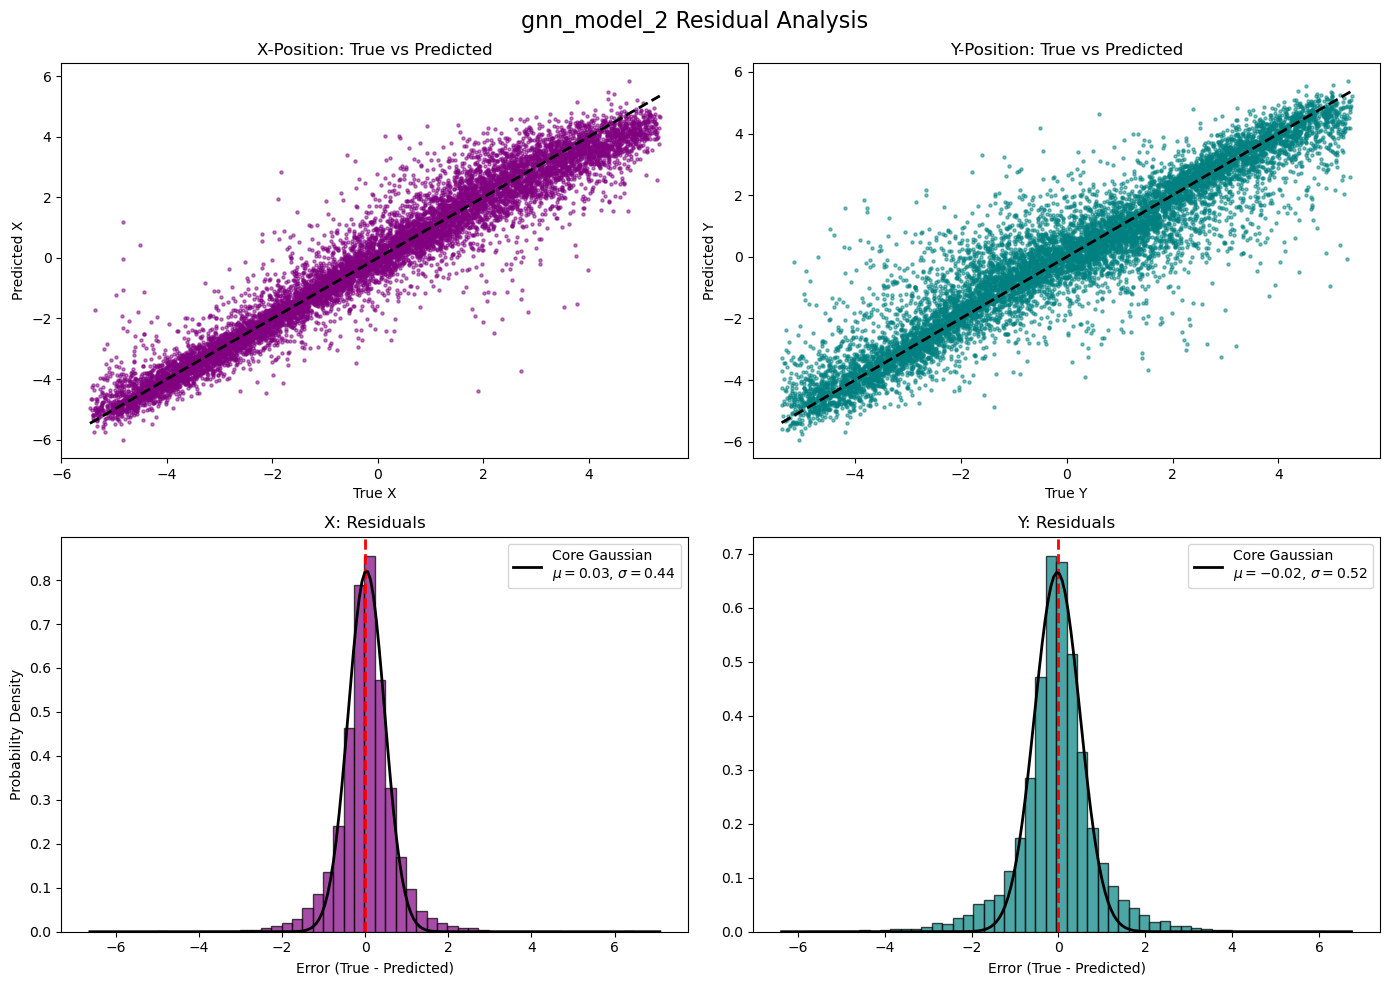

Median Spatial Resolution: 0.64 units


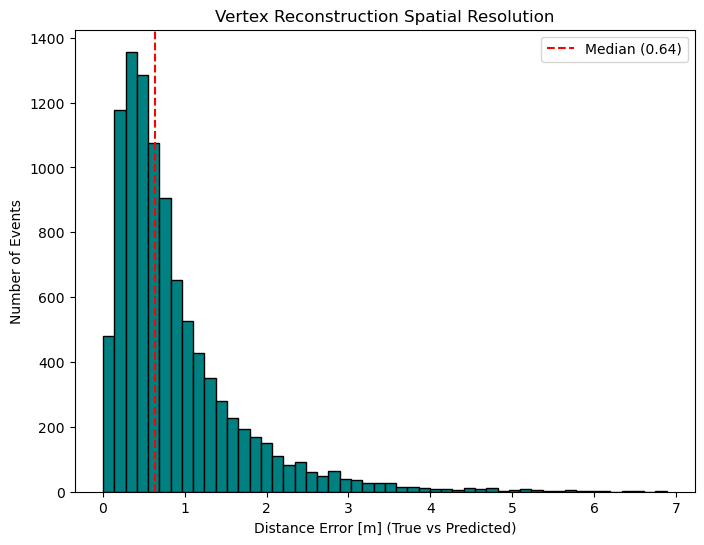

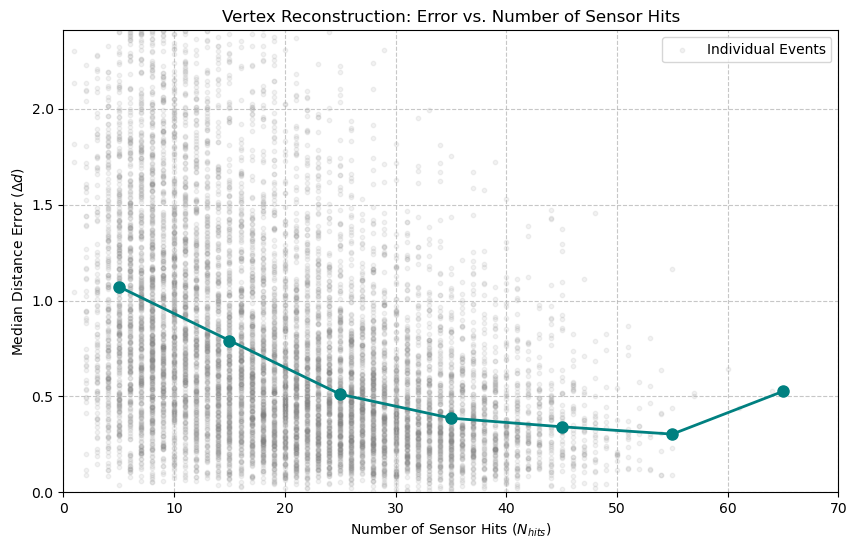

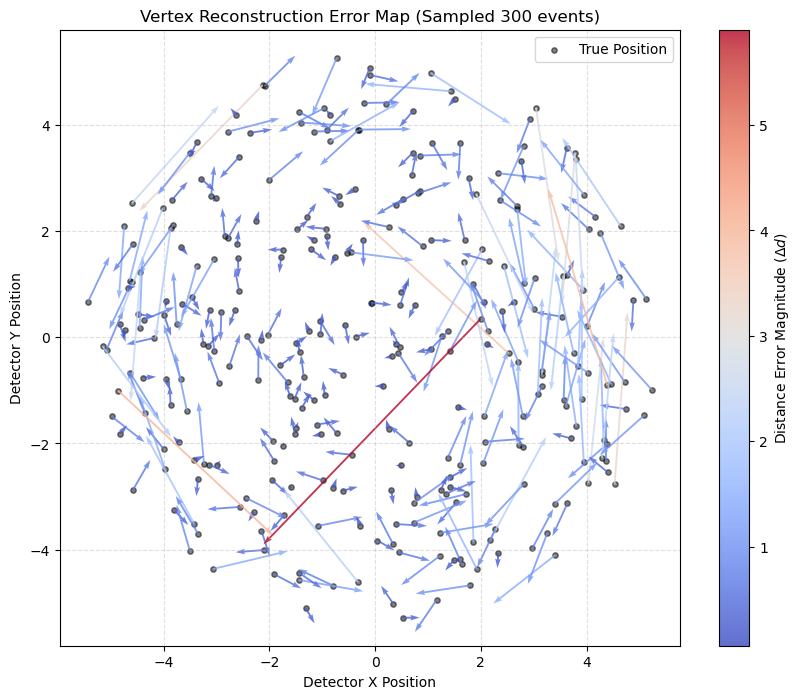

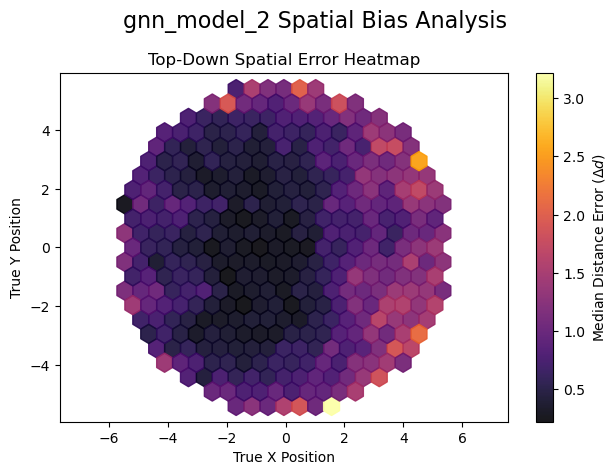

Evaluation complete!


In [15]:
model_name = "gnn_model_2"
model = GNNEncoder(input_dim, hidden_dim, output_dim, num_classes, k)
best_model = load_best_model(model, f"./models/{model_name}.pth", device)
evaluate_model(best_model, test_loader, device, model_name)